ایمپورت ها و بارگذاری دیتا

In [67]:
from datasets import load_dataset
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

In [68]:
# Load the full dataset
dataset = load_dataset("divarofficial/real_estate_ads")

df = dataset["train"].to_pandas()
df.head(5)

,cat2_slug,cat3_slug,city_slug,neighborhood_slug,created_at_month,user_type,description,title,rent_mode,rent_value,...,property_type,regular_person_capacity,extra_person_capacity,cost_per_extra_person,rent_price_on_regular_days,rent_price_on_special_days,rent_price_at_weekends,location_latitude,location_longitude,location_radius
0,temporary-rent,villa,karaj,mehrshahr,2024-08-01 00:00:00,مشاور املاک,۵۰۰متر\n۲۰۰متر بنا دوبلکس\n۳خواب\nاستخر آبگرم ...,باغ ویلا اجاره روزانه استخر داخل لشکرآباد سهیلیه,None,NaN,...,None,4.0,6,350000.0,1500000.0,3.500000e+09,3500000.0,35.811684,50.936600,500.0
1,residential-sell,apartment-sell,tehran,gholhak,2024-05-01 00:00:00,مشاور املاک,دسترسی عالی به مترو و شریعتی \nمشاعات تمیز \nب...,۶۰ متر قلهک فول امکانات,None,NaN,...,None,NaN,None,NaN,NaN,NaN,NaN,NaN,NaN,500.0
2,residential-rent,apartment-rent,tehran,tohid,2024-10-01 00:00:00,None,تخلیه پایان ماه,آپارتمان ۳ خوابه ۱۳۲ متر,مقطوع,26000000.0,...,None,NaN,None,NaN,NaN,NaN,NaN,35.703865,51.373459,NaN
3,commercial-rent,office-rent,tehran,elahiyeh,2024-06-01 00:00:00,None,فرشته تاپ لوکیشن\n۹۰ متر موقعیت اداری\nیک اتاق...,فرشته ۹۰ متر دفتر کار مدرن موقعیت اداری,مقطوع,95000000.0,...,None,NaN,None,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,residential-sell,apartment-sell,mashhad,emamreza,2024-05-01 00:00:00,مشاور املاک,هلدینگ ساختمانی اکبری\n\nهمراه شما هستیم برای ...,۱۱۵ متری/شمالی رو به آفتاب/اکبری,None,NaN,...,None,NaN,None,NaN,NaN,NaN,NaN,NaN,NaN,NaN


تحلیل 1: میانه قیمت هر متر آپارتمان فروشی در تهران، مشهد، کرج و اصفهان چقدر است و گرانترین و ارزانترین محله قابل اعتماد هر شهر کدام است؟

ساخت جدول آگهی های فروش مسکونی

In [69]:
sell_df = df[df["cat2_slug"] == "residential-sell"].copy()

In [70]:
sell_df.columns

Index(['cat2_slug', 'cat3_slug', 'city_slug', 'neighborhood_slug',
       'created_at_month', 'user_type', 'description', 'title', 'rent_mode',
       'rent_value', 'rent_to_single', 'rent_type', 'price_mode',
       'price_value', 'credit_mode', 'credit_value', 'rent_credit_transform',
       'transformable_price', 'transformable_credit', 'transformed_credit',
       'transformable_rent', 'transformed_rent', 'land_size', 'building_size',
       'deed_type', 'has_business_deed', 'floor', 'rooms_count',
       'total_floors_count', 'unit_per_floor', 'has_balcony', 'has_elevator',
       'has_warehouse', 'has_parking', 'construction_year', 'is_rebuilt',
       'has_water', 'has_warm_water_provider', 'has_electricity', 'has_gas',
       'has_heating_system', 'has_cooling_system', 'has_restroom',
       'has_security_guard', 'has_barbecue', 'building_direction', 'has_pool',
       'has_jacuzzi', 'has_sauna', 'floor_material', 'property_type',
       'regular_person_capacity', 'extra_person

In [71]:
sell_df.shape

(558708, 60)

In [72]:
sell_df[
    ["city_slug",
    "neighborhood_slug",
    "price_value",
    "building_size",
    "rooms_count",
    "construction_year",
    "floor",
    "has_elevator",
    "has_warehouse",
    "has_parking",
    "has_balcony",
    "user_type"]
].info()

<class 'pandas.core.frame.DataFrame'>
Index: 558708 entries, 1 to 999997
Data columns (total 12 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   city_slug          558707 non-null  object 
 1   neighborhood_slug  225190 non-null  object 
 2   price_value        534964 non-null  float64
 3   building_size      558677 non-null  float64
 4   rooms_count        425118 non-null  object 
 5   construction_year  425119 non-null  object 
 6   floor              303377 non-null  object 
 7   has_elevator       303378 non-null  object 
 8   has_warehouse      425117 non-null  object 
 9   has_parking        425118 non-null  object 
 10  has_balcony        316327 non-null  object 
 11  user_type          167420 non-null  object 
dtypes: float64(2), object(10)
memory usage: 55.4+ MB


محاسبه قیمت فروش هر متر مربع

In [73]:
sell_df["price_per_sqm"] = (sell_df["price_value"]/sell_df["building_size"])

بررسی اوتلایرها

In [74]:
sell_df["price_per_sqm"].describe()

count    5.349450e+05
mean     1.189154e+08
std      4.674581e+09
min      0.000000e+00
25%      1.282051e+07
50%      2.722222e+07
75%      4.814815e+07
max      1.587302e+12
Name: price_per_sqm, dtype: float64

In [75]:
sell_df[[
    "price_value",
    "building_size",
    "price_per_sqm"
]].describe()

,price_value,building_size,price_per_sqm
count,5.349640e+05,5.586770e+05,5.349450e+05
mean,1.689669e+10,3.438430e+03,1.189154e+08
std,5.796982e+11,1.147996e+05,4.674581e+09
min,0.000000e+00,1.000000e+00,0.000000e+00
25%,1.400000e+09,8.000000e+01,1.282051e+07
50%,2.800000e+09,1.150000e+02,2.722222e+07
75%,5.750000e+09,2.000000e+02,4.814815e+07
max,1.000000e+14,1.000000e+07,1.587302e+12


تعداد ثبت شده قیمت/مساحت/قیمت هر متر مربع

In [76]:
print("total:", len(sell_df))
print("valid_price:", sell_df["price_value"].notna().sum())
print("valid_building_size:", sell_df["building_size"].notna().sum())
print("valid_price_per_sqm:", sell_df["price_per_sqm"].notna().sum())

total: 558708
valid_price: 534964
valid_building_size: 558677
valid_price_per_sqm: 534945


تعداد "صفر" ثبت شده قیمت/ مساحت/ قیمت هر متر مربع

In [77]:
print("zero_price:",(sell_df["price_value"] <= 0).sum())
print("zero_building_size:",(sell_df["building_size"] <= 0).sum())
print("zero_price_per_sqm:",(sell_df["price_per_sqm"] <= 0).sum())

zero_price: 1703
zero_building_size: 0
zero_price_per_sqm: 1703


ساخت دیتاست تحلیلی برای قیمت و مساحت فروش مسکونی غیر صفر

In [78]:
analysis_df = sell_df[
    (sell_df["price_value"] > 0) &
    (sell_df["building_size"] > 0)
].copy()

In [79]:
analysis_df.shape

(533242, 61)

توزیع قیمت هر متر مربع/ بررسی صدک های مختلف برای تشخیص اوتلایرها

خروجی نشان میدهد داده های بسیار بزرگ و بسیار کوچک در داده وجود دارند و داده نیاز به پاکسازی دارد

In [80]:
analysis_df["price_per_sqm"].describe(
    percentiles=[0.01, 0.05, 0.10, 0.25, 0.50, 0.75, 0.90, 0.95, 0.99]
)

count    5.332420e+05
mean     1.192951e+08
std      4.682035e+09
min      8.100446e-05
1%       1.111000e+03
5%       7.758690e+05
10%      2.553191e+06
25%      1.300000e+07
50%      2.731959e+07
75%      4.831830e+07
90%      9.300000e+07
95%      1.328358e+08
99%      3.000000e+08
max      1.587302e+12
Name: price_per_sqm, dtype: float64

مشاهده بیشترین و کمترین قیمت های هر متر مربغ

In [81]:
analysis_df["price_per_sqm"].sort_values().head(20)

853757    0.000081
838264    0.000100
495554    0.000100
444576    0.000100
609117    0.000179
992055    0.000370
587935    0.000482
789480    0.000500
148112    0.000555
379431    0.000556
147660    0.000640
565531    0.000999
715837    0.000999
159080    0.000999
616370    0.001000
904584    0.001000
204184    0.001000
884484    0.001333
890183    0.001333
968574    0.001429
Name: price_per_sqm, dtype: float64

In [82]:
analysis_df["price_per_sqm"].sort_values(ascending=False).head(20)

709118    1.587302e+12
116854    1.204819e+12
740491    1.176471e+12
613784    1.111111e+12
786984    1.000000e+12
60067     8.333333e+11
588194    3.225806e+11
560251    3.122807e+11
339009    3.110000e+11
6406      2.830189e+11
449029    2.777778e+11
323841    2.600000e+11
388408    2.500000e+11
209643    2.406542e+11
418450    2.238636e+11
362549    2.222222e+11
564384    2.083333e+11
398402    2.058824e+11
764378    2.057613e+11
53609     2.054054e+11
Name: price_per_sqm, dtype: float64

میانه قیمت های هر متر مربع(قیمت پیشنهادی) بر اساس شهر ها همراه با تعداد آگهی های ثبت شده

In [83]:
city_price = (
    analysis_df
    .groupby("city_slug")["price_per_sqm"]
    .agg(
        median_price_per_sqm="median",
        listing_count="count"
    )
    .sort_values("median_price_per_sqm", ascending=False)
)

خروجی زیر نشان میدهد کیش بالاترین میانه قیمت ثبت شده به ازای هر متر مربع را بر اساس آگهی های ثبت شده در دیوار در سال 1403 داراست

In [84]:
city_price.head(20)

,median_price_per_sqm,listing_count
city_slug,,
kish,1.000000e+08,1797
tehran,8.400000e+07,93527
fasham-city,6.111111e+07,227
lavasan-city,6.000000e+07,419
shemshak,5.750000e+07,49
salman-shahr,4.970588e+07,694
garmdareh,4.314961e+07,789
shiraz,3.666667e+07,17537
isfahan,3.500000e+07,19114


خروجی زیر نشان میدهد طبقده کمترین میزان قیمت به ازای هر متر مربع را در میان آگهی های ثبت شده در دیوار داراست
اما این خروجی به دلیل تعداد کم آگهی(7 مورد) زیاد قابل اتکا نیست

In [85]:
city_price.tail(20)

,median_price_per_sqm,listing_count
city_slug,,
tabaghdeh,2.413793e+06,7
khalil-shahr,2.375734e+06,10
ferdows,2.333333e+06,123
faragi,2.300000e+06,11
shal,2.181315e+06,46
nokandeh,2.000000e+06,17
saman-city,1.984127e+06,57
mohr,1.873333e+06,28
rostamkola,1.800000e+06,23


مشاهده اوتلایرها

20 آگهی با بزرگترین قیمت ها

In [86]:
analysis_df.loc[
    analysis_df["price_per_sqm"].nlargest(20).index,
    [
        "city_slug",
        "neighborhood_slug",
        "price_value",
        "building_size",
        "price_per_sqm",
        "rooms_count",
        "construction_year",
        "property_type"
    ]
]

,city_slug,neighborhood_slug,price_value,building_size,price_per_sqm,rooms_count,construction_year,property_type
709118,sirjan,None,1.111111e+13,7.0,1.587302e+12,None,None,None
116854,bojnurd,None,1.000000e+14,83.0,1.204819e+12,دو,۱۳۹۵,None
740491,khomam,None,1.000000e+14,85.0,1.176471e+12,دو,۱۴۰۳,None
613784,tabriz,None,1.111111e+12,1.0,1.111111e+12,بدون اتاق,۱۴۰۰,None
786984,chenaran,None,1.000000e+14,100.0,1.000000e+12,دو,۱۴۰۳,None
60067,hamedan,None,5.000000e+13,60.0,8.333333e+11,None,None,None
588194,karaj,malard,1.000000e+14,310.0,3.225806e+11,دو,۱۳۹۹,None
560251,tehran,zafaraniyeh,8.900000e+13,285.0,3.122807e+11,سه,۱۴۰۲,None
339009,tehran,aghdasieh,8.397000e+13,270.0,3.110000e+11,چهار,۱۳۹۲,None
6406,tehran,jamaran,9.000000e+13,318.0,2.830189e+11,چهار,۱۴۰۳,None


20 آگهی با کوچکترین قیمت ها

In [87]:
analysis_df.loc[
    analysis_df["price_per_sqm"].nsmallest(20).index,
    [
        "city_slug",
        "neighborhood_slug",
        "price_value",
        "building_size",
        "price_per_sqm",
        "rooms_count",
        "construction_year",
        "property_type"
    ]
]

,city_slug,neighborhood_slug,price_value,building_size,price_per_sqm,rooms_count,construction_year,property_type
853757,isfahan,abshar-isfahan,1.0,12345.0,0.000081,یک,۱۴۰۳,None
838264,dogonbadan,None,10.0,100150.0,0.000100,یک,۱۳۹۶,None
444576,farrokhshahr,None,1.0,10000.0,0.000100,چهار,۱۳۹۷,None
495554,jiroft,None,10.0,100000.0,0.000100,چهار,۱۴۰۲,None
609117,shiraz,dokuhak,1.0,5600.0,0.000179,دو,۱۳۹۵,None
992055,varamin-city,None,1.0,2700.0,0.000370,بدون اتاق,۱۳۹۱,None
587935,shiraz,saadiyeh,1.0,2074.0,0.000482,بدون اتاق,۱۴۰۰,None
789480,tuyserkan,None,5.0,10000.0,0.000500,بدون اتاق,قبل از ۱۳۷۰,None
148112,ahvaz,shariatijonoobi,111.0,200000.0,0.000555,سه,۱۴۰۰,None
379431,bojnurd,None,1.0,1800.0,0.000556,یک,قبل از ۱۳۷۰,None


آگهی های زیر متری یک میلیون تومان فلگ شدند

In [88]:
analysis_df["invalid_ppsqm_low_flag"] = (
    analysis_df["price_per_sqm"] < 1_000_000
)
analysis_df["invalid_ppsqm_low_flag"].value_counts()

invalid_ppsqm_low_flag
False    503077
True      30165
Name: count, dtype: int64

آگهی های بالای صدک 99 فلگ شدند(یک درصد بسیار گران)

In [89]:
p99 = analysis_df["price_per_sqm"].quantile(0.99)


analysis_df["extreme_ppsqm_high_flag"] = (
    analysis_df["price_per_sqm"] > p99
)

analysis_df["extreme_ppsqm_high_flag"].value_counts()


extreme_ppsqm_high_flag
False    528050
True       5192
Name: count, dtype: int64

صدک 99:

In [90]:
p99

np.float64(300000000.0)

داده های قابل اعتماد و ولید

In [91]:
analysis_valid = analysis_df[
    (analysis_df["price_per_sqm"] >= 1_000_000) &
    (analysis_df["price_per_sqm"] <= p99)
].copy()

قیمت ها بر اساس شهر ها

In [92]:
city_price = (
    analysis_valid
    .groupby("city_slug")["price_per_sqm"]
    .agg(
        median_price_per_sqm="median",
        listing_count="count"
    )
    .sort_values("median_price_per_sqm", ascending=False)
)

چون تعداد آگهی ها مهم است و روی قابل اعتماد بودن تحلیل اثر دارد، حداقل تعداد آگهی ها را 100 در نظر میگیرم

In [93]:
city_price_reliable = city_price[
    city_price["listing_count"] >= 100
]

بیشترین قیمت هر متر برای داده های قابل اعتماد بر اساس شهر

In [94]:
city_price_reliable.head(20)

,median_price_per_sqm,listing_count
city_slug,,
kish,1.000000e+08,1700
tehran,8.333333e+07,89884
fasham-city,6.000000e+07,213
lavasan-city,5.658654e+07,376
salman-shahr,5.000000e+07,666
garmdareh,4.330127e+07,774
shiraz,3.833333e+07,16115
hamedan,3.593750e+07,4087
isfahan,3.577507e+07,17992


کمترین قیمت هر متر برای داده های قابل اعتکماد در هر شهر

In [95]:
city_price_reliable.tail(20)

,median_price_per_sqm,listing_count
city_slug,,
baft,6.470588e+06,171
javadabad,6.428571e+06,106
minab,6.400000e+06,283
shaft,6.200000e+06,345
rostam-abad,6.095238e+06,104
mehriz,6.000000e+06,113
zabol,5.909091e+06,603
chaf-chamkhale,5.882353e+06,597
khormoj,5.844402e+06,132


بررسی شهرهای نام برده شده در متن توضیح پروژه

خروجی زیر نشان میدهد تهران بالاترین قیمت هر متر مربع را داراست. میانه قیمت آن 83 میلیون تومان است.
و مشهد با میانه قیمت 31 میلیون تومان کمترین قیمت هر متر مربع را دارد.
از میانه استفاده کردم تا نسبت به اوتلایر ها حساسیت کمتری داشته باشد.

In [96]:
target_cities = [
    "tehran",
    "mashhad",
    "karaj",
    "isfahan"
]

city_price_reliable[
    city_price_reliable.index.isin(target_cities)
]

,median_price_per_sqm,listing_count
city_slug,,
tehran,8.333333e+07,89884
isfahan,3.577507e+07,17992
karaj,3.333333e+07,26337
mashhad,3.100000e+07,32492


بررسی قیمت محله های هر شهر. با تعداد حداقل 50 آگهی

In [97]:
neighborhood_price = (
    analysis_valid
    .dropna(subset=["neighborhood_slug"])
    .groupby(["city_slug", "neighborhood_slug"])["price_per_sqm"]
    .agg(
        median_price_per_sqm="median",
        listing_count="count"
    )
)

In [98]:
neighborhood_price_reliable = neighborhood_price[
    neighborhood_price["listing_count"] >= 50
].sort_values(
    "median_price_per_sqm",
    ascending=False
)

محله ها از گرانترین به ارزانترین
20 محله گران از تهران هستند

In [99]:
neighborhood_price_reliable.head(20)

median_price_per_sqm  listing_count
city_slug neighborhood_slug                                     
tehran    velenjak                   2.222222e+08            447
          zafaraniyeh                2.195122e+08            659
          elahiyeh                   2.173913e+08            539
          mahmoodiyeh                2.143451e+08             90
          kamraniyeh                 2.142857e+08            151
          hesar-booali               2.000000e+08             50
          farmaniyeh                 1.977953e+08            558
          aghdasieh                  1.959274e+08            226
          darrous                    1.900000e+08            648
          niavaran                   1.894737e+08            791
          jamaran                    1.890861e+08             62
          eivanak                    1.877816e+08             76
          emamzade-ghasem            1.815789e+08             59
          dezashib                   1.812500e+08            100
          shahrak-e-gharb            1.790541e+08            441
          hekmat                     1.755556e+08            191
          chizar                     1.711720e+08             50
          ajoodanieh                 1.681592e+08            211
          kashanak                   1.675676e+08             71
          qeytariyeh                 1.675338e+08            902

10 محله گران هر شهر همراه با آگهی

In [100]:
for city in ["tehran", "mashhad", "karaj", "isfahan"]:
    print(f"\n{city.upper()}:")
    print(
        neighborhood_price_reliable
        .loc[city]
        .head(10)
    )


TEHRAN:
                   median_price_per_sqm  listing_count
neighborhood_slug                                     
velenjak                   2.222222e+08            447
zafaraniyeh                2.195122e+08            659
elahiyeh                   2.173913e+08            539
mahmoodiyeh                2.143451e+08             90
kamraniyeh                 2.142857e+08            151
hesar-booali               2.000000e+08             50
farmaniyeh                 1.977953e+08            558
aghdasieh                  1.959274e+08            226
darrous                    1.900000e+08            648
niavaran                   1.894737e+08            791

MASHHAD:
                   median_price_per_sqm  listing_count
neighborhood_slug                                     
malek-abad-garden          1.000000e+08             91
sadjadshahr                9.166667e+07            513
felestin                   6.515625e+07             96
ahmadabad                  6.500000e+07       

تحلیل 2: آسانسور، پاارکینگ، انباری، طبقه ، سن بنا، تعداد اتاق، و جهت ساختمان چه  ارتباطی با قیمت هر متر مربع دارند؟

دسته بندی مساحت ها

In [101]:
analysis_valid["area_group"] = pd.cut(
    analysis_valid["building_size"],
    bins=[0, 50, 80, 120, 150, 200, 300, float("inf")],
    labels=[
        "≤50",
        "51-80",
        "81-120",
        "121-150",
        "151-200",
        "201-300",
        "300+"
    ]
)

بررسی قیمت هر متر مربع بر اساس  گروه متراژ

In [102]:
area_price = (
    analysis_valid
    .groupby("area_group", observed=True)["price_per_sqm"]
    .agg(
        median_price_per_sqm="median",
        listing_count="count"
    )
)

خروجی زیر نشان میدهد قیمت ها برای متراژ بالای 200 متر به ازای هر متر مربع کاهش پیدا کرده است. 

In [103]:
area_price

,median_price_per_sqm,listing_count
area_group,,
≤50,3.795018e+07,25112
51-80,2.962963e+07,110181
81-120,3.023256e+07,155136
121-150,3.503401e+07,60538
151-200,2.800000e+07,59381
201-300,1.523810e+07,44691
300+,6.506957e+06,42846


بررسی سال ساخت و تبدیل آن به اعداد انگلیسی و int

In [104]:
analysis_valid["construction_year"].value_counts().head(20)

construction_year
۱۴۰۳           76451
۱۴۰۲           36616
۱۴۰۰           22331
۱۳۹۵           21753
۱۳۹۰           21717
۱۴۰۱           18655
۱۳۹۷           17154
۱۳۹۶           16778
۱۳۹۸           16665
۱۳۸۵           15212
۱۳۹۳           14764
۱۳۹۴           13553
۱۳۹۹           13117
۱۳۹۲           12694
۱۳۸۸           11637
۱۳۸۰            9082
۱۳۹۱            8255
۱۳۸۹            8119
قبل از ۱۳۷۰     8095
۱۳۸۷            7312
Name: count, dtype: int64

In [105]:
analysis_valid["construction_year"].isna().sum()

np.int64(91642)

In [106]:
persian_digits = str.maketrans(
    "۰۱۲۳۴۵۶۷۸۹",
    "0123456789"
)

analysis_valid["construction_year_num"] = (
    analysis_valid["construction_year"]
    .astype("string")
    .str.translate(persian_digits)
    .str.replace("قبل از ۱۳۷۰", "1369", regex=False)
    .pipe(pd.to_numeric, errors="coerce")
)

In [107]:
analysis_valid["construction_year_num"].value_counts().head(20)

construction_year_num
1403    76451
1402    36616
1400    22331
1395    21753
1390    21717
1401    18655
1397    17154
1396    16778
1398    16665
1385    15212
1393    14764
1394    13553
1399    13117
1392    12694
1388    11637
1380     9082
1391     8255
1389     8119
1387     7312
1386     7247
Name: count, dtype: Int64

In [108]:
analysis_valid["construction_year_num"].describe()

count       398148.0
mean     1395.067967
std         7.488305
min           1371.0
25%           1390.0
50%           1397.0
75%           1402.0
max           1403.0
Name: construction_year_num, dtype: Float64

ساخت ستون سن ساختمان

In [109]:
analysis_valid["building_age"] = (
    1404 - analysis_valid["construction_year_num"]
)

بررسی داده های سن

In [110]:
analysis_valid["building_age"].describe()

count    398148.0
mean     8.932033
std      7.488305
min           1.0
25%           2.0
50%           7.0
75%          14.0
max          33.0
Name: building_age, dtype: Float64

گروه بندی سن

In [111]:
analysis_valid["age_group"] = pd.cut(
    analysis_valid["building_age"],
    bins=[0, 5, 10, 20, 30, float("inf")],
    labels=[
        "0-5 سال",
        "6-10 سال",
        "11-20 سال",
        "21-30 سال",
        "30+ سال"
    ]
)

بررسی رابطه سن ساختمان با قیمت

In [112]:
age_price = (
    analysis_valid
    .groupby("age_group", observed=True)["price_per_sqm"]
    .agg(
        median_price_per_sqm="median",
        listing_count="count"
    )
)

فعلا رابطه خاصی بین سن و قیمت مشاهده نمیشود

In [113]:
print(age_price)

           median_price_per_sqm  listing_count
age_group                                     
0-5 سال            3.200000e+07         167170
6-10 سال           3.076923e+07          85903
11-20 سال          3.338348e+07         111908
21-30 سال          4.307692e+07          29100
30+ سال            3.529412e+07           4067


بررسی امکانات

In [114]:
analysis_valid["has_parking"].value_counts(dropna=False)

has_parking
True     334079
None      91642
False     72164
Name: count, dtype: int64

In [115]:
analysis_valid["has_elevator"].value_counts(dropna=False)

has_elevator
True     213825
None     203325
False     80735
Name: count, dtype: int64

In [116]:
analysis_valid["has_warehouse"].value_counts(dropna=False)

has_warehouse
True     347731
None      91642
False     58512
Name: count, dtype: int64

In [117]:
analysis_valid["has_balcony"].value_counts(dropna=False)

has_balcony
true        255829
None        196808
false        45151
unselect        97
Name: count, dtype: int64

ساخت تابع برای بررسی رابطه قیمت با امکانات. اتعداد آگهی ها نیز ثبت شده است تا قابل اعتماد بودن تحلیل بررسی شود

In [118]:
def feature_price_analysis(df, feature):
    return (
        df.dropna(subset=[feature])
        .groupby(feature)["price_per_sqm"]
        .agg(
            median_price_per_sqm="median",
            listing_count="count"
        )
        .sort_values("median_price_per_sqm", ascending=False)
    )

In [119]:
parking_price = feature_price_analysis(
    analysis_valid,
    "has_parking"
)

elevator_price = feature_price_analysis(
    analysis_valid,
    "has_elevator"
)

warehouse_price = feature_price_analysis(
    analysis_valid,
    "has_warehouse"
)

balcony_price = feature_price_analysis(
    analysis_valid,
    "has_balcony"
)

خروجی زیر نشان میدهد رابطه مثبت بین وجود امکانات و قیمت وجود دارد اما این رابطه شدید نست./ داده های نن بررسی نشده اند.

In [120]:
print("PARKING")
print(parking_price)

print("\nELEVATOR")
print(elevator_price)

print("\nWAREHOUSE")
print(warehouse_price)

print("\nBALCONY")
print(balcony_price)

PARKING
             median_price_per_sqm  listing_count
has_parking                                     
True                 3.450000e+07         334079
False                2.333333e+07          72164

ELEVATOR
              median_price_per_sqm  listing_count
has_elevator                                     
True                  4.000000e+07         213825
False                 2.857143e+07          80735

WAREHOUSE
               median_price_per_sqm  listing_count
has_warehouse                                     
True                   3.400000e+07         347731
False                  2.532343e+07          58512

BALCONY
             median_price_per_sqm  listing_count
has_balcony                                     
true                   33000000.0         255829
unselect               27750000.0             97
false                  25000000.0          45151


داده های بالا نتیجه خاصی و قابل اتکایی نشان نمیدهند پس میرویم سراغ ساخت مدل رگرسیونی چندگانه  برای امکانات

از جدول analysis_valid لگاریتم میگیریم زیرا داده ها چوله هستند

In [121]:
analysis_valid["log_price_per_sqm"] = np.log(
    analysis_valid["price_per_sqm"])

In [122]:
analysis_valid["log_price_per_sqm"].describe()

count    497885.000000
mean         17.044805
std           1.080762
min          13.815511
25%          16.552381
50%          17.172856
75%          17.720613
max          19.519293
Name: log_price_per_sqm, dtype: float64

عددی کردن متغیر متنی

In [123]:
analysis_valid["rooms_num"] = (
    analysis_valid["rooms_count"]
    .replace({
        "بدون اتاق": 0,
        "یک": 1,
        "دو": 2,
        "سه": 3,
        "چهار": 4,
        "پنج یا بیشتر": 5
    })
)
analysis_valid["rooms_num"] = pd.to_numeric(
    analysis_valid["rooms_num"],
    errors="coerce"
)
analysis_valid["rooms_num"].dtype

C:\Users\lenovo\AppData\Local\Temp\ipykernel_7412\312016353.py:3: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  .replace({


dtype('float64')

مدل نهایی که دنبالشیم: log(Price/m2)=β0​+β1​Elevator+β2​Parking+β3​Warehouse+...
(بررسی اثر وجود آسانسور، انباری، تعداد اتاق، سن بنا، جهت ساختمان،طبقه و پارکینگ روی قیمت)


استفاده از کتابخانه statsmodels برای تحلیل رگرسیونی

In [124]:
import statsmodels.api as sm

model_df = analysis_valid[
    [
        "log_price_per_sqm",
        "has_elevator",
        "has_parking",
        "has_warehouse",
        "building_age",
        "rooms_num",
        "floor",
        "building_direction"
    ]
].copy()

تبدیل متغیرهای بولین به عددی

In [125]:
for col in ["has_elevator", "has_parking", "has_warehouse"]:
    model_df[col] = model_df[col].map({
        True: 1,
        False: 0
    })

str to int

In [126]:
analysis_valid["floor"].value_counts(dropna=False).head(30)

floor
None    203325
2        70623
3        62691
1        61923
4        42214
5        21992
0        14211
6         8193
7         3240
8         1783
10        1347
9         1236
11         902
-1         796
12         767
13         516
14         505
30+        381
15         263
16         176
17         147
18         116
20         110
19          86
25          62
21          58
22          47
23          44
30          38
24          29
Name: count, dtype: int64

In [127]:
analysis_valid["building_direction"].value_counts(dropna=False)

building_direction
None        300092
south        97643
north        86659
east          7257
west          4260
unselect      1974
Name: count, dtype: int64

In [128]:
#model_df = analysis_valid[
   # [
    #    "log_price_per_sqm",
     #   "building_size",
      #  "building_age",
       # "rooms_num",
        #"has_elevator",
        #"has_parking",
        #"has_warehouse",
        #"floor",
        #"building_direction",
        #"city_slug"
    #]
#].copy()


# -------------------------
# Binary variables
# -------------------------

#for col in ["has_elevator", "has_parking", "has_warehouse"]:
 #   model_df[col] = model_df[col].map({
  #      True: 1,
   #     False: 0
    #})


# -------------------------
# Floor
# -------------------------

#model_df["floor_num"] = (
 #   model_df["floor"]
  #  .astype("string")
   # .replace("30+", "31")
    #.pipe(pd.to_numeric, errors="coerce")
#)


# -------------------------
# Direction
# -------------------------

#model_df["building_direction"] = (
 #   model_df["building_direction"]
  #  .replace("unselect", np.nan))

categorical to dummy

In [129]:
#model_df = pd.get_dummies(
 #   model_df,
  #  columns=[
   #     "building_direction",
    #    "city_slug"
    #],
    #drop_first=True,
    #dtype=float
#)

In [130]:
#model_df = model_df.dropna()
#print(model_df.shape)
#print(model_df.dtypes)

ساخت x,y

In [131]:
#X = model_df.drop(
 #   columns=["log_price_per_sqm"]
#)

#y = model_df["log_price_per_sqm"]

#X = sm.add_constant(X)

چون به ارور خوردیم تبدیل دوباره همه چیز به float

In [133]:

#model_df = analysis_valid[
    #[
        #"log_price_per_sqm",
        #"building_size",
        #"building_age",
        #"rooms_num",
        #"has_elevator",
        #"has_parking",
        #"has_warehouse",
        #"floor",
        #"building_direction",
        #"city_slug"
    #]
#
# ].copy()


# Binary variables
#for col in ["has_elevator", "has_parking", "has_warehouse"]:
    # model_df[col] = model_df[col].map({
    #     True: 1,
    #     False: 0
    # })


# Floor
#model_df["floor_num"] = (
    #model_df["floor"]
    #.astype("string")
    #.replace("30+", "30")
    #.pipe(pd.to_numeric, errors="coerce")
#)


# Direction
#model_df["building_direction"] = (
   # model_df["building_direction"]
    #.replace("unselect", np.nan)
#)


# حذف floor متنی
#model_df = model_df.drop(columns=["floor"])


# Dummy variables
#model_df = pd.get_dummies(
    #model_df,
    #columns=["building_direction", "city_slug"],
    #drop_first=True,
    #dtype=float
#)


# حذف missing
#model_df = model_df.dropna()


#model_df = model_df.astype("float64")


# X و y
#X = model_df.drop(columns=["log_price_per_sqm"])
#y = model_df["log_price_per_sqm"]


# Constant
#X = sm.add_constant(X)


# کنترل نهایی
#print(X.dtypes.value_counts())
#print("X shape:", X.shape)
#print("y shape:", y.shape)

ساخت مدل

In [135]:
#model = sm.OLS(y, X).fit()

#print(model.summary())

مرحل بالا بخاطر نکشیدن رم به مشکل خورد. از sklearn استفاده میکنیم.

In [136]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

model_df = analysis_valid[
    [
        "log_price_per_sqm",
        "building_size",
        "building_age",
        "rooms_num",
        "has_elevator",
        "has_parking",
        "has_warehouse",
        "floor",
        "building_direction",
        "city_slug"
    ]
].copy()

تبدیل باینری به اینت

In [137]:

for col in ["has_elevator", "has_parking", "has_warehouse"]:
    model_df[col] = model_df[col].map({
        True: 1,
        False: 0
    })

# floor
model_df["floor_num"] = (
    model_df["floor"]
    .astype("string")
    .replace("30+", "30")
    .pipe(pd.to_numeric, errors="coerce")
)

# direction
model_df["building_direction"] = (
    model_df["building_direction"]
    .replace("unselect", np.nan)
)

model_df = model_df.drop(columns=["floor"])

# حذف missing
model_df = model_df.dropna()

In [138]:
X = model_df.drop(columns=["log_price_per_sqm"])
y = model_df["log_price_per_sqm"]

In [139]:
categorical_features = [
    "building_direction",
    "city_slug"
]

numeric_features = [
    "building_size",
    "building_age",
    "rooms_num",
    "floor_num",
    "has_elevator",
    "has_parking",
    "has_warehouse"
]

In [140]:
preprocessor = ColumnTransformer(
    transformers=[
        (
            "categorical",
            OneHotEncoder(
                drop="first",
                handle_unknown="ignore",
                sparse_output=True
            ),
            categorical_features
        ),
        (
            "numeric",
            "passthrough",
            numeric_features
        )
    ]
)

مثل اینکه دراپ های زیادی که کردیم یک ستونو کاملا خالی کرده

In [141]:
#X_encoded = preprocessor.fit_transform(X)

#print(X_encoded.shape)

In [142]:
print(X.shape)
print(X[categorical_features].shape)

print("\nMissing:")
print(X[categorical_features].isna().sum())

print("\nUnique:")
print(X[categorical_features].nunique())

print(X.head())
print(X.dtypes)

(154293, 9)
(154293, 2)

Missing:
building_direction    0
city_slug             0
dtype: int64

Unique:
building_direction      4
city_slug             344
dtype: int64
    building_size  building_age  rooms_num  has_elevator  has_parking  \
4           115.0             1        2.0           1.0          1.0   
8            78.0             8        2.0           1.0          1.0   
10           87.0             1        2.0           1.0          1.0   
12          169.0             1        3.0           1.0          1.0   
30           64.0             4        1.0           0.0          0.0   

    has_warehouse building_direction      city_slug  floor_num  
4             1.0              north        mashhad          4  
8             1.0              north  mahdasht-city          4  
10            1.0              north    pardis-city          4  
12            1.0              south        mashhad          2  
30            0.0              south         pishva          1  
bu

شروع دوباره

In [143]:
reg_df = analysis_valid[
    [
        "log_price_per_sqm",
        "building_size",
        "building_age",
        "rooms_num",
        "has_elevator",
        "has_parking",
        "has_warehouse",
        "floor",
        "building_direction",
        "city_slug"
    ]
].copy()


# امکانات
for col in ["has_elevator", "has_parking", "has_warehouse"]:
    reg_df[col] = reg_df[col].map({
        True: 1,
        False: 0
    })


# طبقه
reg_df["floor_num"] = (
    pd.to_numeric(
        reg_df["floor"]
        .astype("string")
        .replace("30+", "30"),
        errors="coerce"
    )
)

reg_df.drop(columns=["floor"], inplace=True)


# جهت
reg_df["building_direction"] = (
    reg_df["building_direction"]
    .replace("unselect", np.nan)
)

به جای حذف یک دسته از میسینگ ها میسازیم

In [144]:
reg_df["building_direction"] = (
    reg_df["building_direction"]
    .fillna("unknown")
)

reg_df["city_slug"] = (
    reg_df["city_slug"]
    .fillna("unknown")
)

In [145]:
reg_df = reg_df.dropna(
    subset=[
        "log_price_per_sqm",
        "building_size",
        "building_age",
        "rooms_num",
        "floor_num"
    ]
)

In [146]:
print(reg_df.shape)
print(reg_df.isna().sum())

(293038, 10)
log_price_per_sqm     0
building_size         0
building_age          0
rooms_num             0
has_elevator          0
has_parking           0
has_warehouse         0
building_direction    0
city_slug             0
floor_num             0
dtype: int64


In [147]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder

categorical_features = [
    "building_direction",
    "city_slug"
]

numeric_features = [
    "building_size",
    "building_age",
    "rooms_num",
    "floor_num",
    "has_elevator",
    "has_parking",
    "has_warehouse"
]

X = reg_df.drop(columns=["log_price_per_sqm"])
y = reg_df["log_price_per_sqm"]

preprocessor = ColumnTransformer(
    transformers=[
        (
            "categorical",
            OneHotEncoder(
                drop="first",
                handle_unknown="ignore",
                sparse_output=True
            ),
            categorical_features
        ),
        (
            "numeric",
            "passthrough",
            numeric_features
        )
    ]
)

X_encoded = preprocessor.fit_transform(X)

print("X shape:", X_encoded.shape)
print("y shape:", y.shape)
print("type:", type(X_encoded))

X shape: (293038, 387)
y shape: (293038,)
type: <class 'scipy.sparse._csr.csr_matrix'>


r2 نشان دهنده میزان توضیح دهندگی مدل است

متغیرهای وارد شده  در مجموع حدود 62 درصد از تغییرات لگاریتم قیمت هر متر مربع را توضیح میدهند

In [148]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

model = LinearRegression()
model.fit(X_encoded, y)

y_pred = model.predict(X_encoded)

print("R²:", r2_score(y, y_pred))

R²: 0.6167560782446491


استخراج ضرایب

In [149]:
feature_names = preprocessor.get_feature_names_out()

coef_df = pd.DataFrame({
    "feature": feature_names,
    "coefficient": model.coef_
})

coef_df["abs_coefficient"] = coef_df["coefficient"].abs()

coef_df.sort_values(
    "abs_coefficient",
    ascending=False
).head(30)

,feature,coefficient,abs_coefficient
190,categorical__city_slug_kish,1.651159,1.651159
110,categorical__city_slug_fasham-city,1.621285,1.621285
203,categorical__city_slug_lavasan-city,1.451908,1.451908
357,categorical__city_slug_tehran,1.280524,1.280524
303,categorical__city_slug_salman-shahr,1.105526,1.105526
147,categorical__city_slug_izadshahr,1.020106,1.020106
283,categorical__city_slug_ramsar,0.885441,0.885441
91,categorical__city_slug_dehloran,-0.775795,0.775795
66,categorical__city_slug_borazjan,-0.759949,0.759949
344,categorical__city_slug_sorkhrood,0.759365,0.759365


ضرایب متغیر ها. اثر سن ساختمان مثبت است!!!!!!!

In [150]:
coef_df[
    coef_df["feature"].str.contains(
        "building_age|rooms_num|floor_num|has_elevator|has_parking|has_warehouse|building_direction",
        regex=True
    )
].sort_values("coefficient", ascending=False)

,feature,coefficient,abs_coefficient
384,numeric__has_elevator,0.239714,0.239714
382,numeric__rooms_num,0.221275,0.221275
385,numeric__has_parking,0.212300,0.212300
1,categorical__building_direction_south,0.088899,0.088899
386,numeric__has_warehouse,0.062968,0.062968
0,categorical__building_direction_north,0.060958,0.060958
2,categorical__building_direction_unknown,0.026590,0.026590
381,numeric__building_age,0.008115,0.008115
383,numeric__floor_num,-0.009999,0.009999
3,categorical__building_direction_west,-0.015209,0.015209


نمونه 50 هزارتایی جدا شد تا رم به مشکل نخورد. 

تفسیر مدل:

In [151]:
import statsmodels.api as sm

# نمونه 50 هزار تایی
sample_idx = np.random.RandomState(42).choice(
    reg_df.index,
    size=50000,
    replace=False
)

sample_df = reg_df.loc[sample_idx].copy()

# dummy کردن فقط نمونه
sample_df = pd.get_dummies(
    sample_df,
    columns=["building_direction", "city_slug"],
    drop_first=True,
    dtype=float
)

# X و y
y_sample = sample_df["log_price_per_sqm"]

X_sample = sample_df.drop(columns=["log_price_per_sqm"])

X_sample = sm.add_constant(X_sample)

# اطمینان از عددی بودن
X_sample = X_sample.astype(float)
y_sample = y_sample.astype(float)

# مدل
ols_model = sm.OLS(y_sample, X_sample).fit()

print(ols_model.summary())

                            OLS Regression Results                            
Dep. Variable:      log_price_per_sqm   R-squared:                       0.626
Model:                            OLS   Adj. R-squared:                  0.624
Method:                 Least Squares   F-statistic:                     251.7
Date:                Sat, 15 Aug 2026   Prob (F-statistic):               0.00
Time:                        00:36:09   Log-Likelihood:                -30871.
No. Observations:               50000   AIC:                         6.241e+04
Df Residuals:                   49668   BIC:                         6.533e+04
Df Model:                         331                                         
Covariance Type:            nonrobust                                         
                                          coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------------------------
co

# تحلیل اثر ویژگی‌های ساختمان بر قیمت هر مترمربع

## 1. هدف تحلیل

هدف این بخش بررسی رابطه بین ویژگی‌های فیزیکی و امکانات ساختمان و
`log_price_per_sqm` (لگاریتم قیمت هر مترمربع) است.

متغیرهای مورد بررسی:

- آسانسور
- پارکینگ
- انباری
- جهت ساختمان
- طبقه
- سن ساختمان
- تعداد اتاق
- شهر

---

## 2. آماده‌سازی داده

برای جلوگیری از اثر شدید مقادیر پرت، متغیر هدف به صورت لگاریتمی تعریف شد:

`log_price_per_sqm = log(price_per_sqm)`

همچنین:

- متغیرهای باینری به 0 و 1 تبدیل شدند.
- `floor` به متغیر عددی تبدیل شد.
- `construction_year` به `building_age` تبدیل شد.
- `rooms_count` به `rooms_num` تبدیل شد.
- متغیر `building_direction` به متغیرهای dummy تبدیل شد.
- `city_slug` نیز به dummy variables تبدیل شد.
- رکوردهای دارای missing در متغیرهای مورد استفاده حذف شدند.

در نهایت:

**293,038 رکورد** برای مدل نهایی مورد استفاده قرار گرفت.

---

## 3. مدل رگرسیون

مدل مورد استفاده:

`log_price_per_sqm ~ building_size + building_age + rooms_num
+ has_elevator + has_parking + has_warehouse
+ building_direction + city_slug + floor_num`

مدل از نوع OLS / Linear Regression است.

### عملکرد مدل

**R² = 0.6166**

یعنی متغیرهای موجود در مدل توانسته‌اند حدود **61.7 درصد از تغییرات
لگاریتم قیمت هر مترمربع** را توضیح دهند.

این مقدار نشان می‌دهد مدل قدرت توضیحی قابل‌توجهی دارد، هرچند هنوز
متغیرهای مهم دیگری مانند محله، زمان معامله، موقعیت جغرافیایی و
ویژگی‌های دیگر ملک می‌توانند قیمت را توضیح دهند.

---

## 4. ضرایب اصلی مدل

| متغیر | ضریب | تفسیر اولیه |
|---|---:|---|
| آسانسور | +0.2387 | رابطه مثبت نسبتاً قوی با قیمت |
| تعداد اتاق | +0.2216 | رابطه مثبت با قیمت |
| پارکینگ | +0.2125 | رابطه مثبت نسبتاً قوی با قیمت |
| جهت جنوب | +0.0747 | رابطه مثبت نسبت به جهت مرجع |
| انباری | +0.0633 | رابطه مثبت با قیمت |
| جهت شمال | +0.0468 | رابطه مثبت نسبت به جهت مرجع |
| سن ساختمان | +0.0081 | رابطه بسیار ضعیف |
| طبقه | -0.0100 | رابطه منفی بسیار ضعیف |

### مهم

این ضرایب **اثر شرطی** هستند؛ یعنی اثر هر متغیر در حالی بررسی شده که
سایر متغیرهای موجود در مدل ثابت نگه داشته شده‌اند.

با این حال، صرفاً مثبت یا منفی بودن ضریب به معنی «اثر معنادار آماری»
نیست. برای این نتیجه باید `p-value` و `confidence interval` را بررسی کنیم.

---

## 5. مهم‌ترین یافته اولیه

در مدل فعلی، در میان متغیرهای امکاناتی:

**آسانسور، تعداد اتاق و پارکینگ بیشترین ضرایب مثبت را دارند.**

این نتیجه با تحلیل ساده قبلی نیز تا حد زیادی سازگار است، اما تفاوت مهم
این است که در مدل رگرسیونی، اثر این متغیرها پس از کنترل همزمان برای
شهر، سن ساختمان، طبقه، جهت و سایر متغیرهای واردشده بررسی شده است

p_value & residual

In [152]:
# جدول ضرایب و معناداری آماری
results = pd.DataFrame({
    "coefficient": ols_model.params,
    "p_value": ols_model.pvalues,
    "ci_lower": ols_model.conf_int()[0],
    "ci_upper": ols_model.conf_int()[1]
})

# فقط متغیرهای اصلی خودمان
main_vars = [
    "has_elevator",
    "has_parking",
    "has_warehouse",
    "building_age",
    "rooms_num",
    "floor_num"
]

results.loc[
    results.index.isin(main_vars)
].sort_values("p_value")

,coefficient,p_value,ci_lower,ci_upper
rooms_num,0.208218,0.000000e+00,0.200941,0.215495
has_elevator,0.243823,0.000000e+00,0.232371,0.255276
has_parking,0.215627,2.681824e-265,0.203555,0.227698
building_age,0.008168,7.294946e-110,0.007451,0.008885
floor_num,-0.010493,8.732407e-32,-0.012245,-0.008741
has_warehouse,0.066173,1.454857e-25,0.053769,0.078576


جهت شمال رابطه معناداری و مثبت با قیمت دارد/ جهت جنوب رابطه مثبت و قوی تری با قیمت دارد/ برای جهت غرب و جهت نامشخص شواهد آماری کافی برای وجود تفاوت با جهت مرجع نداریم

In [153]:
results[
    results.index.str.contains("building_direction", na=False)
]

,coefficient,p_value,ci_lower,ci_upper
building_direction_north,0.048879,0.003039,0.016556,0.081202
building_direction_south,0.073958,0.000006,0.041899,0.106018
building_direction_unknown,0.011320,0.483314,-0.020332,0.042972
building_direction_west,0.010845,0.670892,-0.039178,0.060868


پسماندها میانگین و میانه کمی دارند و این نشان میدهد در مرکز نزدیک صفر هستند اما دامنه نسبتا بزرگ دارند. این یعنی خطای پیش بینی وجود دارد/ اما مدل قابل استفاده است(با توجه به آر2 = 61.7%)

In [154]:
residuals = ols_model.resid

print("Mean residual:", residuals.mean())
print("Std residual:", residuals.std())

print("\nResidual percentiles:")
print(
    residuals.describe(
        percentiles=[0.01, 0.05, 0.25, 0.50, 0.75, 0.95, 0.99]
    )
)

Mean residual: 1.6639653210859252e-13
Std residual: 0.4486498284907847

Residual percentiles:
count    5.000000e+04
mean     1.663965e-13
std      4.486498e-01
min     -4.611284e+00
1%      -1.486227e+00
5%      -6.753131e-01
25%     -2.016306e-01
50%      2.430114e-02
75%      2.443149e-01
95%      6.296893e-01
99%      9.763027e-01
max      2.682277e+00
dtype: float64


اسکترپلات توزیع پسماندها

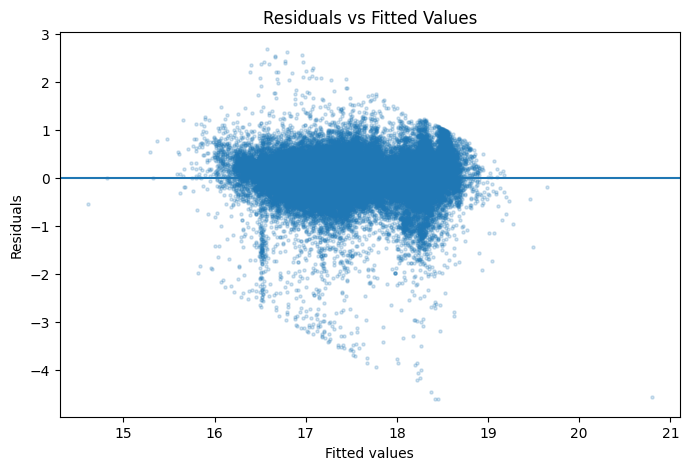

In [155]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
plt.scatter(
    ols_model.fittedvalues,
    residuals,
    s=5,
    alpha=0.2
)

plt.axhline(0)
plt.xlabel("Fitted values")
plt.ylabel("Residuals")
plt.title("Residuals vs Fitted Values")
plt.show()

تحلیل 3: تعداد آگهی های فروش مسکونی در ماه های موجود چه تغییری کرده است و آیا روند تغییر قیمت پیشنهادی با روند عرضه هم جهت است؟

میانه قیمت هر متر مربع بر اسااس هر ماه/ ماه های ابتدایی تعداد آگهی های کمی دارند و قابل اتکا نیستند.

In [156]:
monthly_market = (
    analysis_df
    .groupby("created_at_month")
    .agg(
        listing_count=("price_per_sqm", "count"),
        median_price_per_sqm=("price_per_sqm", "median")
    )
    .reset_index()
    .sort_values("created_at_month")
)

monthly_market

,created_at_month,listing_count,median_price_per_sqm
0,2021-02-01 00:00:00,1,2.200000e+08
1,2021-06-01 00:00:00,1,8.000000e+06
2,2022-01-01 00:00:00,1,2.000000e+06
3,2022-02-01 00:00:00,1,2.640264e+06
4,2022-04-01 00:00:00,2,2.583747e+06
5,2022-05-01 00:00:00,2,5.624549e+07
6,2022-06-01 00:00:00,1,1.046512e+08
7,2022-07-01 00:00:00,1,1.142857e+07
8,2022-08-01 00:00:00,5,2.298851e+07
9,2022-10-01 00:00:00,3,2.750000e+07


In [157]:
print(monthly_market.head())
print(monthly_market.tail())

print(monthly_market.shape)

      created_at_month  listing_count  median_price_per_sqm
0  2021-02-01 00:00:00              1          2.200000e+08
1  2021-06-01 00:00:00              1          8.000000e+06
2  2022-01-01 00:00:00              1          2.000000e+06
3  2022-02-01 00:00:00              1          2.640264e+06
4  2022-04-01 00:00:00              2          2.583747e+06
       created_at_month  listing_count  median_price_per_sqm
34  2024-11-01 00:00:00          69143          2.823529e+07
35  2024-12-01 00:00:00          67736          2.916667e+07
36  2025-01-01 00:00:00            785          3.538462e+07
37  2025-02-01 00:00:00            116          3.137090e+07
38  2025-03-01 00:00:00              4          4.477328e+07
(39, 3)


نمودار روند تعداد آگهی

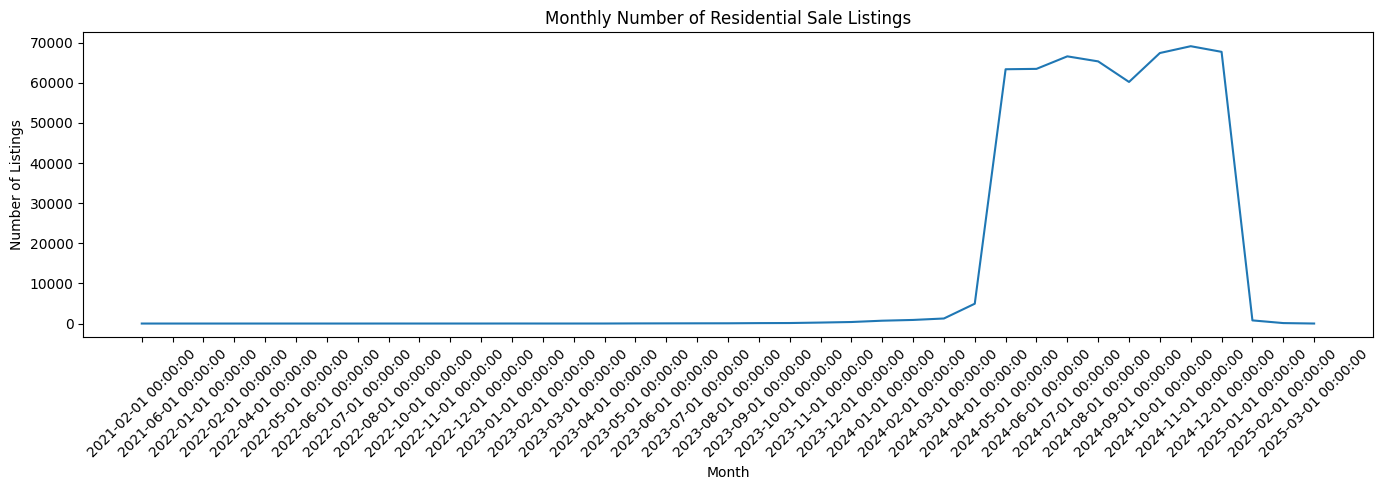

In [158]:
import matplotlib.pyplot as plt

monthly = (
    analysis_df
    .groupby("created_at_month")
    .agg(
        listing_count=("price_per_sqm", "count"),
        median_price_per_sqm=("price_per_sqm", "median")
    )
    .reset_index()
)

plt.figure(figsize=(14, 5))

plt.plot(
    monthly["created_at_month"],
    monthly["listing_count"]
)

plt.title("Monthly Number of Residential Sale Listings")
plt.xlabel("Month")
plt.ylabel("Number of Listings")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

نمودار روند قیمت پیشنهادی

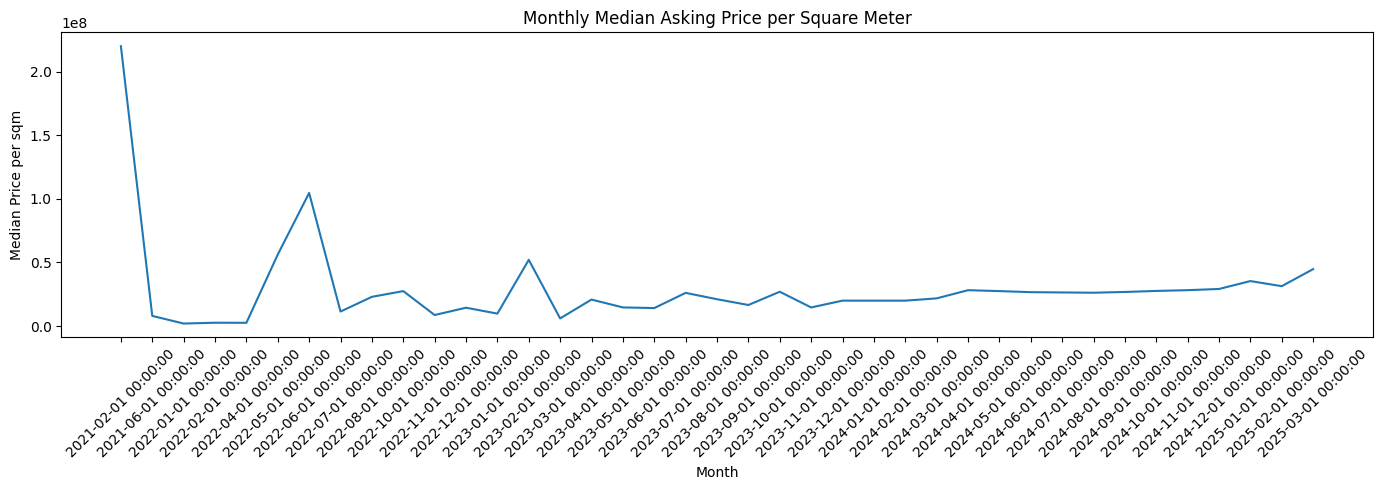

In [159]:
plt.figure(figsize=(14, 5))

plt.plot(
    monthly["created_at_month"],
    monthly["median_price_per_sqm"]
)

plt.title("Monthly Median Asking Price per Square Meter")
plt.xlabel("Month")
plt.ylabel("Median Price per sqm")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

هر دو روند در کنار هم

در بخش قابل اتکای داده، یعنی اواخر 2024، تعداد آگهی‌های فروش مسکونی در سطح بالایی قرار داشته و قیمت پیشنهادی نیز روندی نسبتاً صعودی داشته است. اما افت شدید تعداد آگهی‌ها در 2025 همراه با کاهش شدید حجم مشاهدات، امکان استنباط مطمئن درباره رابطه عرضه و قیمت را محدود می‌کند. بنابراین برای بررسی هم‌جهتی واقعی دو روند، باید ماه‌های با تعداد آگهی کافی را مبنا قرار داد.

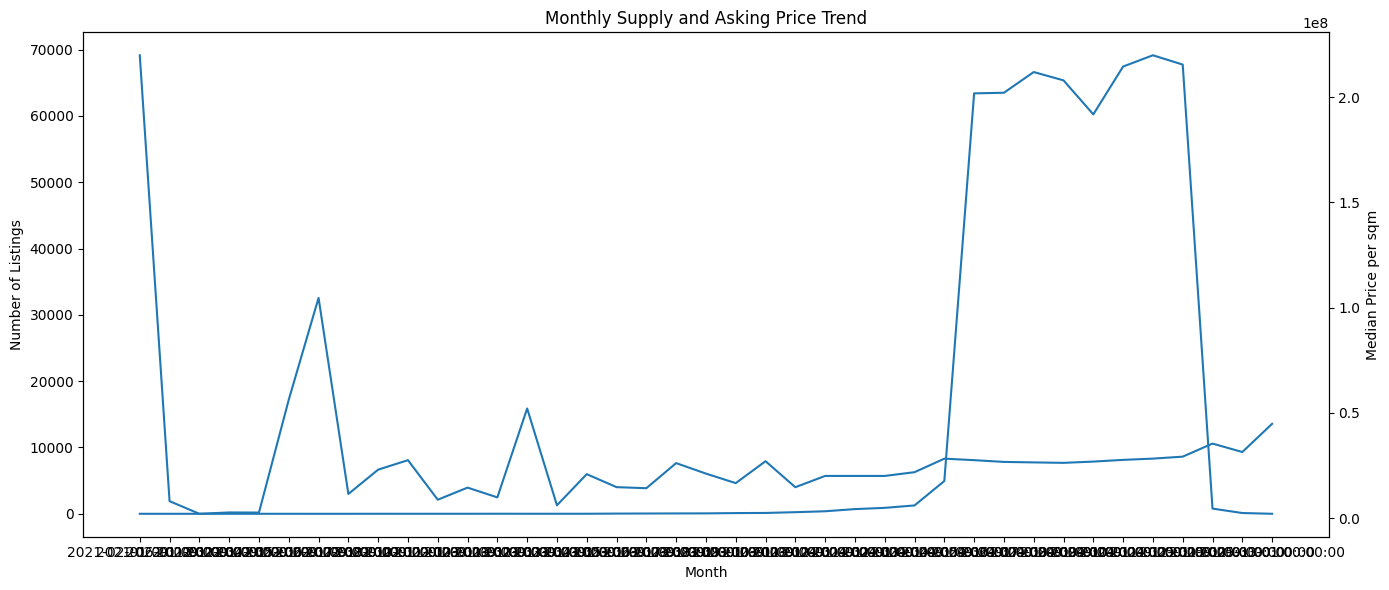

In [160]:
fig, ax1 = plt.subplots(figsize=(14, 6))

ax1.plot(
    monthly["created_at_month"],
    monthly["listing_count"],
    label="Listing Count"
)

ax1.set_xlabel("Month")
ax1.set_ylabel("Number of Listings")

ax2 = ax1.twinx()

ax2.plot(
    monthly["created_at_month"],
    monthly["median_price_per_sqm"],
    label="Median Price per sqm"
)

ax2.set_ylabel("Median Price per sqm")

plt.title("Monthly Supply and Asking Price Trend")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

فیلتر حداقل تعداد آگهی:

In [161]:
monthly_valid = monthly[
    monthly["listing_count"] >= 1000
].copy()

print(monthly_valid)

       created_at_month  listing_count  median_price_per_sqm
26  2024-03-01 00:00:00           1260          2.177979e+07
27  2024-04-01 00:00:00           4944          2.821547e+07
28  2024-05-01 00:00:00          63397          2.750000e+07
29  2024-06-01 00:00:00          63491          2.666667e+07
30  2024-07-01 00:00:00          66613          2.643678e+07
31  2024-08-01 00:00:00          65357          2.622222e+07
32  2024-09-01 00:00:00          60230          2.681818e+07
33  2024-10-01 00:00:00          67442          2.763158e+07
34  2024-11-01 00:00:00          69143          2.823529e+07
35  2024-12-01 00:00:00          67736          2.916667e+07


شاید تعداد آگهی های ماه های اول بشدت کمه چون قبلا تاحدودی اوتلایرهارو حذف کردیم

بنابراین دوباره از df یه دیتافریم جدید میسازم

In [162]:
print(df.shape)
print(df.columns.tolist())

(1000000, 60)
['cat2_slug', 'cat3_slug', 'city_slug', 'neighborhood_slug', 'created_at_month', 'user_type', 'description', 'title', 'rent_mode', 'rent_value', 'rent_to_single', 'rent_type', 'price_mode', 'price_value', 'credit_mode', 'credit_value', 'rent_credit_transform', 'transformable_price', 'transformable_credit', 'transformed_credit', 'transformable_rent', 'transformed_rent', 'land_size', 'building_size', 'deed_type', 'has_business_deed', 'floor', 'rooms_count', 'total_floors_count', 'unit_per_floor', 'has_balcony', 'has_elevator', 'has_warehouse', 'has_parking', 'construction_year', 'is_rebuilt', 'has_water', 'has_warm_water_provider', 'has_electricity', 'has_gas', 'has_heating_system', 'has_cooling_system', 'has_restroom', 'has_security_guard', 'has_barbecue', 'building_direction', 'has_pool', 'has_jacuzzi', 'has_sauna', 'floor_material', 'property_type', 'regular_person_capacity', 'extra_person_capacity', 'cost_per_extra_person', 'rent_price_on_regular_days', 'rent_price_on_s

In [163]:
print(
    df["created_at_month"]
    .value_counts()
    .sort_index()
    .tail(15)
)

created_at_month
2024-01-01 00:00:00       942
2024-02-01 00:00:00      1211
2024-03-01 00:00:00      1881
2024-04-01 00:00:00      7187
2024-05-01 00:00:00    108759
2024-06-01 00:00:00    125624
2024-07-01 00:00:00    133219
2024-08-01 00:00:00    132396
2024-09-01 00:00:00    121432
2024-10-01 00:00:00    126387
2024-11-01 00:00:00    121456
2024-12-01 00:00:00    116452
2025-01-01 00:00:00      1139
2025-02-01 00:00:00       148
2025-03-01 00:00:00         5
Name: count, dtype: int64


In [164]:
supply_monthly = (
    df.groupby("created_at_month")
     .size()
     .reset_index(name="listing_count")
     .sort_values("created_at_month")
)

print(supply_monthly)

       created_at_month  listing_count
0   2020-02-01 00:00:00              1
1   2020-12-01 00:00:00              1
2   2021-02-01 00:00:00              1
3   2021-05-01 00:00:00              1
4   2021-06-01 00:00:00              1
5   2021-11-01 00:00:00              1
6   2021-12-01 00:00:00              2
7   2022-01-01 00:00:00              1
8   2022-02-01 00:00:00              2
9   2022-03-01 00:00:00              1
10  2022-04-01 00:00:00              5
11  2022-05-01 00:00:00              7
12  2022-06-01 00:00:00              4
13  2022-07-01 00:00:00              4
14  2022-08-01 00:00:00              9
15  2022-09-01 00:00:00              6
16  2022-10-01 00:00:00              6
17  2022-11-01 00:00:00              9
18  2022-12-01 00:00:00             11
19  2023-01-01 00:00:00             17
20  2023-02-01 00:00:00             17
21  2023-03-01 00:00:00             25
22  2023-04-01 00:00:00             23
23  2023-05-01 00:00:00             53
24  2023-06-01 00:00:00  

از تعداد آگهی ها قبل از حذف اوتلایرها استفاده میکنیم

In [165]:
sale_df = df[df["cat2_slug"] == "residential-sell"].copy()

print(sale_df.shape)

(558708, 60)


In [166]:
monthly_supply = (
    sale_df
    .groupby("created_at_month")
    .size()
    .reset_index(name="listing_count")
    .sort_values("created_at_month")
)

print(monthly_supply)

       created_at_month  listing_count
0   2020-02-01 00:00:00              1
1   2021-02-01 00:00:00              1
2   2021-05-01 00:00:00              1
3   2021-06-01 00:00:00              1
4   2021-11-01 00:00:00              1
5   2022-01-01 00:00:00              1
6   2022-02-01 00:00:00              1
7   2022-04-01 00:00:00              2
8   2022-05-01 00:00:00              2
9   2022-06-01 00:00:00              1
10  2022-07-01 00:00:00              1
11  2022-08-01 00:00:00              6
12  2022-09-01 00:00:00              1
13  2022-10-01 00:00:00              4
14  2022-11-01 00:00:00              5
15  2022-12-01 00:00:00              6
16  2023-01-01 00:00:00             10
17  2023-02-01 00:00:00              8
18  2023-03-01 00:00:00              7
19  2023-04-01 00:00:00              9
20  2023-05-01 00:00:00             36
21  2023-06-01 00:00:00             44
22  2023-07-01 00:00:00             59
23  2023-08-01 00:00:00             67
24  2023-09-01 00:00:00  

همچنان از میانه قیمت قابل اعتماد استفاده میکنیم

In [167]:
monthly_price = (
    analysis_df
    .groupby("created_at_month")["price_per_sqm"]
    .median()
    .reset_index(name="median_price_per_sqm")
)

مرج کردن دو نتیحه بالا

In [168]:
monthly_analysis = monthly_supply.merge(
    monthly_price,
    on="created_at_month",
    how="left"
)

print(monthly_analysis)

       created_at_month  listing_count  median_price_per_sqm
0   2020-02-01 00:00:00              1                   NaN
1   2021-02-01 00:00:00              1          2.200000e+08
2   2021-05-01 00:00:00              1                   NaN
3   2021-06-01 00:00:00              1          8.000000e+06
4   2021-11-01 00:00:00              1                   NaN
5   2022-01-01 00:00:00              1          2.000000e+06
6   2022-02-01 00:00:00              1          2.640264e+06
7   2022-04-01 00:00:00              2          2.583747e+06
8   2022-05-01 00:00:00              2          5.624549e+07
9   2022-06-01 00:00:00              1          1.046512e+08
10  2022-07-01 00:00:00              1          1.142857e+07
11  2022-08-01 00:00:00              6          2.298851e+07
12  2022-09-01 00:00:00              1                   NaN
13  2022-10-01 00:00:00              4          2.750000e+07
14  2022-11-01 00:00:00              5          8.695652e+06
15  2022-12-01 00:00:00 

روند تعداد آگهی‌های فروش مسکونی و روند قیمت پیشنهادی در بخش اصلی داده‌ها، در برخی دوره‌ها هم‌جهت بوده‌اند، اما رابطه‌ی واضح و پایدار و علّی مشاهده نمی‌شود.

In [169]:
monthly_valid = monthly[
    (monthly["created_at_month"] >= "2024-05-01") &
    (monthly["created_at_month"] <= "2024-12-01")
].copy()

correlation = monthly_valid[
    ["listing_count", "median_price_per_sqm"]
].corr()

print(correlation)

                      listing_count  median_price_per_sqm
listing_count              1.000000              0.458264
median_price_per_sqm       0.458264              1.000000


عرضه:
از ابتدای ۲۰۲۴ تعداد آگهی‌ها به‌شدت افزایش یافته و در ماه‌های می تا دسامبر ۲۰۲۴ در محدوده حدود ۶۳ تا ۷۲ هزار آگهی در ماه قرار گرفته است. سپس در ژانویه ۲۰۲۵ به ۷۹۶ و در فوریه به ۱۲۰ آگهی سقوط کرده؛ بنابراین ماه‌های انتهایی احتمالاً ناقص‌اند و برای تحلیل روند مناسب نیستند.

قیمت:
در ماه‌های پرتعداد ۲۰۲۴، قیمت از حدود ۲۱.۸ میلیون تومان/مترمربع در مارس به حدود ۲۹.۲ میلیون در دسامبر رسیده است.

بنابراین در بخش قابل‌اتکاتر داده، عرضه و قیمت پیشنهادی در مجموع هم‌جهت حرکت کرده‌اند؛ و ضریب همبستگی ماهانه +0.458 نیز این هم‌جهتی متوسط را تأیید می‌کند.

تحلیل روی ماه های قابل اتکاتر

In [170]:
monthly_reliable = monthly_analysis[
    (monthly_analysis["created_at_month"] >= "2024-05-01") &
    (monthly_analysis["created_at_month"] <= "2024-12-31")
].copy()

print(monthly_reliable)

print("\nCorrelation:")
print(
    monthly_reliable[
        ["listing_count", "median_price_per_sqm"]
    ].corr()
)

       created_at_month  listing_count  median_price_per_sqm
32  2024-05-01 00:00:00          66688          2.750000e+07
33  2024-06-01 00:00:00          66789          2.666667e+07
34  2024-07-01 00:00:00          70039          2.643678e+07
35  2024-08-01 00:00:00          68674          2.622222e+07
36  2024-09-01 00:00:00          63075          2.681818e+07
37  2024-10-01 00:00:00          70409          2.763158e+07
38  2024-11-01 00:00:00          72168          2.823529e+07
39  2024-12-01 00:00:00          70599          2.916667e+07

Correlation:
                      listing_count  median_price_per_sqm
listing_count              1.000000              0.478058
median_price_per_sqm       0.478058              1.000000


در بازه May تا Dec 2024، روند عرضه و قیمت پیشنهادی مسکن در مجموع هم‌جهت بوده‌اند؛ افزایش تعداد آگهی‌ها با افزایش قیمت پیشنهادی همراه شده است. بااین‌حال، شدت رابطه متوسط است و این همبستگی به‌تنهایی به معنی رابطه علّی نیست.

تحلیل 4: محله ها بر اساس قیمت، مساحت و امکانات و نوع ملک در چه بخش هایی از بازار قرار میگیرند؟

مشخص کردن انواع ملک

In [171]:
sell_df["property_type"].value_counts(dropna=False)

property_type
None               536017
jungle              15061
other                2950
beach                2725
jungle-mountain      1805
mountain              150
Name: count, dtype: int64

In [172]:
sell_df["cat3_slug"].value_counts(dropna=False)

cat3_slug
apartment-sell      303385
plot-old            133570
house-villa-sell    121753
Name: count, dtype: int64

بنابراین cat3=plot_old برابر با زمین سرمایه ای خواهد بود

In [173]:
market_df = sell_df[
    sell_df["cat3_slug"].isin([
        "apartment-sell",
        "house-villa-sell",
        "plot-old"
    ])
].copy()

market_df["cat3_slug"].value_counts()

cat3_slug
apartment-sell      303385
plot-old            133570
house-villa-sell    121753
Name: count, dtype: int64

In [174]:
built_df = sell_df[
    sell_df["cat3_slug"].isin([
        "apartment-sell",
        "house-villa-sell"
    ])
].copy()

land_df = sell_df[
    sell_df["cat3_slug"] == "plot-old"
].copy()

مشاهده رنج قیمتی خانه های مسکونی

In [175]:
built_df.groupby("cat3_slug")["price_per_sqm"].describe(
    percentiles=[0.25, 0.50, 0.75, 0.90])

,count,mean,std,min,25%,50%,75%,90%,max
cat3_slug,,,,,,,,,
apartment-sell,303377.0,1.285700e+08,3.577259e+09,0.0,2.402778e+07,3.593750e+07,6.198347e+07,1.097758e+08,1.204819e+12
house-villa-sell,121738.0,1.405326e+08,5.993822e+09,0.0,1.250000e+07,2.181818e+07,3.714286e+07,6.590909e+07,1.176471e+12


مشهده رنج مساحت خانه های مسکونی

In [176]:
built_df.groupby("cat3_slug")["building_size"].describe(
    percentiles=[0.25, 0.50, 0.75, 0.90])

,count,mean,std,min,25%,50%,75%,90%,max
cat3_slug,,,,,,,,,
apartment-sell,303380.0,499.038348,45145.289111,1.0,72.0,90.0,120.0,156.0,10000000.0
house-villa-sell,121738.0,2543.323309,98090.498322,1.0,90.0,130.0,200.0,320.0,10000000.0


خلاصه امکانات:

In [177]:
amenities = [
    "has_parking",
    "has_elevator",
    "has_warehouse",
    "has_balcony"
]

built_df[amenities].apply(
    lambda x: x.map({
        True: 1,
        False: 0,
        "true": 1,
        "false": 0
    }).mean()
)

has_parking      0.820379
has_elevator     0.725563
has_warehouse    0.852570
has_balcony      0.843370
dtype: float64

حذف قیمت های پرت و ساخت آستانه

In [178]:
# فقط آپارتمان و خانه/ویلا
market_df = sell_df[
    sell_df["cat3_slug"].isin(["apartment-sell", "house-villa-sell"])
].copy()

# قیمت کل معتبر
market_df = market_df[
    market_df["price_value"].notna() &
    (market_df["price_value"] > 0)
].copy()

# حذف پرت‌های شدید قیمت کل بر اساس هر نوع ملک
price_limits = (
    market_df.groupby("cat3_slug")["price_value"]
    .quantile([0.01, 0.99])
    .unstack()
)

price_limits.columns = ["p01", "p99"]

market_df = market_df.join(price_limits, on="cat3_slug")

market_df = market_df[
    market_df["price_value"].between(
        market_df["p01"],
        market_df["p99"]
    )
].copy()

print(market_df.shape)

(415371, 63)


آستانه قیمتی هر نوع ملک

In [179]:
price_thresholds = (
    market_df.groupby("cat3_slug")["price_value"]
    .quantile([0.25, 0.50, 0.75])
    .unstack()
)

price_thresholds.columns = ["Q1", "Median", "Q3"]

price_thresholds

,Q1,Median,Q3
cat3_slug,,,
apartment-sell,1.900000e+09,3.300000e+09,6.250000e+09
house-villa-sell,1.500000e+09,2.700000e+09,5.500000e+09


گروه مساحت

In [180]:
df["area_group"] = pd.cut(
    df["building_size"],
    bins=[0, 50, 80, 120, 200, float("inf")],
    labels=["کوچک", "متوسط", "بزرگ", "خیلی بزرگ", "بسیار بزرگ"]
)

امکانات لاکچری:

In [181]:
luxury_amenity_columns = [  
"has_security_guard",
    "has_barbecue",
    "has_pool",
    "has_jacuzzi",
    "has_sauna"]
df["luxury_amenity_count"] = df[luxury_amenity_columns].eq(True).sum(axis=1)

In [182]:
df["luxury_amenity_level"] = pd.cut(
    df["luxury_amenity_count"],
    bins=[-1, 2, 4, 5, float("inf")],
    labels=["کم", "متوسط", "زیاد", "لوکس"])

In [183]:
# اضافه کردن شاخص امکانات لوکس به market_df
market_df["luxury_amenity_level"] = df.loc[
    market_df.index, "luxury_amenity_level"
]
market_df["area_group"] = df.loc[
    market_df.index, "area_group"
]


In [184]:
pd.crosstab(
    market_df["cat3_slug"],
    market_df["luxury_amenity_level"],
    normalize="index"
).round(3)

luxury_amenity_level,کم,متوسط,زیاد
cat3_slug,,,
apartment-sell,1.000,0.00,0.000
house-villa-sell,0.984,0.01,0.006


In [185]:
pd.crosstab(
    market_df["cat3_slug"],
    market_df["area_group"],
    normalize="index"
).round(3)

area_group,کوچک,متوسط,بزرگ,خیلی بزرگ,بسیار بزرگ
cat3_slug,,,,,
apartment-sell,0.062,0.313,0.391,0.209,0.026
house-villa-sell,0.058,0.140,0.285,0.291,0.226


ساخت مارکت سگمنت

In [186]:
# زمین سرمایه‌ای
#market_df["market_segment"] = np.nan

#market_df.loc[
 #   market_df["cat3_slug"] == "plot-old",
  #  "market_segment"
#] = "زمین سرمایه‌ای"

In [187]:
segment_df = sell_df[
    sell_df["cat3_slug"].isin([
        "apartment-sell",
        "house-villa-sell",
        "plot-old"
    ])
].copy()

اعمال استانه قیمت

In [188]:
segment_df["market_segment"] = "میان‌رده"

# زمین سرمایه‌ای
segment_df.loc[
    segment_df["cat3_slug"] == "plot-old",
    "market_segment"
] = "زمین سرمایه‌ای"

# آپارتمان
apt = segment_df["cat3_slug"] == "apartment-sell"

segment_df.loc[
    apt & (segment_df["price_value"] <= 1.9e9),
    "market_segment"
] = "اقتصادی"

segment_df.loc[
    apt &
    (segment_df["price_value"] > 6.25e9),
    "market_segment"
] = "لوکس"

# خانه و ویلا
villa = segment_df["cat3_slug"] == "house-villa-sell"

segment_df.loc[
    villa & (segment_df["price_value"] <= 1.5e9),
    "market_segment"
] = "اقتصادی"

segment_df.loc[
    villa &
    (segment_df["price_value"] > 5.5e9),
    "market_segment"
] = "لوکس"

تعریف لوکس با کنترل مساحت و قیمت

In [189]:
large_area = segment_df["building_size"] >= 200

segment_df.loc[
    (segment_df["market_segment"] == "لوکس") &
    (~large_area),
    "market_segment"
] = "میان‌رده"

In [190]:
segment_df["market_segment"].value_counts()

market_segment
میان‌رده          284503
زمین سرمایه‌ای    133570
اقتصادی           113062
لوکس               27573
Name: count, dtype: int64

In [191]:
segment_df["market_segment"].value_counts(normalize=True).mul(100).round(2)

market_segment
میان‌رده          50.92
زمین سرمایه‌ای    23.91
اقتصادی           20.24
لوکس               4.94
Name: proportion, dtype: float64

نتایج بالا نشان میدهد بازار عمدتا میان رده است 

محله ها در کدام بخش قرار دارند؟

In [192]:
#neighborhood_market = pd.crosstab(
 #   segment_df["neighborhood_slug"],
  #  segment_df["market_segment"],
   # normalize="index"
#).mul(100).round(2)

#neighborhood_market.head()

In [193]:
segment_share = pd.crosstab(
    segment_df["neighborhood_slug"],
    segment_df["market_segment"],
    normalize="index"
).mul(100)

segment_cols = [
    "اقتصادی",
    "میان‌رده",
    "لوکس",
    "زمین سرمایه‌ای"
]

segment_cols = [
    col for col in segment_cols
    if col in segment_share.columns
]

neighborhood_count = (
    segment_df["neighborhood_slug"]
    .value_counts()
    .rename("listing_count")
)

neighborhood_market = segment_share.join(neighborhood_count)

neighborhood_market = neighborhood_market[
    neighborhood_market["listing_count"] >= 50
].copy()

neighborhood_market["dominant_segment"] = (
    neighborhood_market[segment_cols].idxmax(axis=1)
)

In [194]:
print(neighborhood_market["dominant_segment"].value_counts())

dominant_segment
میان‌رده          616
اقتصادی            62
زمین سرمایه‌ای     52
لوکس                5
Name: count, dtype: int64


In [195]:
for segment in segment_cols:
    print(f"\n===== {segment} =====")
    print(
        neighborhood_market
        .sort_values(segment, ascending=False)
        [[segment, "listing_count", "dominant_segment"]]
        .head(10)
    )


===== اقتصادی =====
                     اقتصادی  listing_count dominant_segment
neighborhood_slug                                           
hojjat             86.222222            225          اقتصادی
hyderabad          81.818182            616          اقتصادی
khorramdasht       78.794179            481          اقتصادی
north-tabars       77.485929           1066          اقتصادی
moeinzadeh         77.464789             71          اقتصادی
kuy-e-daravey      75.806452             62          اقتصادی
isargaran          75.100402            249          اقتصادی
marlik             72.928526           1581          اقتصادی
shahrak-alborz     72.566372            113          اقتصادی
mahdiabad          71.875000             64          اقتصادی

===== میان‌رده =====
                       میان‌رده  listing_count dominant_segment
neighborhood_slug                                              
eram                  98.226950            282         میان‌رده
kooy-e-bimeh          97.727273  

نتایج نشان می‌دهد ساختار بازار مسکن در محله‌های مختلف یکسان نیست. برخی محله‌ها عمدتاً اقتصادی، برخی به‌شدت میان‌رده، برخی دارای سهم بالای املاک لوکس و برخی دیگر تحت سلطه آگهی‌های زمین سرمایه‌ای هستند. در سطح کل بازار، بخش میان‌رده با حدود ۵۱٪ بیشترین سهم را دارد، در حالی که بازار لوکس تنها حدود ۵٪ آگهی‌ها را تشکیل می‌دهد. بنابراین می‌توان گفت تفاوت محله‌ها بیشتر در ترکیب Segmentهای بازار است تا صرفاً سطح قیمت آنها.

تحلیل 5: کدام شهر ها یا محله ها بازار داغ تر و کدام مناطق بازار سردتری دارند

مفهوم بازار سرد: listing_count(number of ads) پایین و میانه قیمت هر متر مربع پایین

مفهوم بازار گرم: listing_count بالا و میانه قیمت هر متر مربع بالا

ساخت دیتافریم محله ها

In [196]:
neighborhood_stats = (
    sell_df
    .groupby("neighborhood_slug")
    .agg(
        listing_count=("neighborhood_slug", "size"),
        median_price_per_sqm=("price_per_sqm", "median")
    )
    .reset_index()
)

# حذف محله‌های کم‌نمونه
neighborhood_stats = neighborhood_stats[
    neighborhood_stats["listing_count"] >= 50
].copy()

تعیین مرز فعالیت و قیمت

In [197]:
count_median = neighborhood_stats["listing_count"].median()
price_median = neighborhood_stats["median_price_per_sqm"].median()

print("Median listing count:", count_median)
print("Median price per sqm:", price_median)

Median listing count: 155.0
Median price per sqm: 44444444.44444445


تقسیم بندی محله ها

In [198]:
neighborhood_stats["market_heat"] = np.select(
    [
        (neighborhood_stats["listing_count"] >= count_median) &
        (neighborhood_stats["median_price_per_sqm"] >= price_median),

        (neighborhood_stats["listing_count"] < count_median) &
        (neighborhood_stats["median_price_per_sqm"] < price_median)
    ],
    [
        "داغ",
        "سرد"
    ],
    default="متوسط"
)

In [199]:
print(
    neighborhood_stats["market_heat"]
    .value_counts()
)

print("\n===== محله‌های داغ =====")
print(
    neighborhood_stats[
        neighborhood_stats["market_heat"] == "داغ"
    ]
    .sort_values(
        ["listing_count", "median_price_per_sqm"],
        ascending=False
    )
    .head(20)
)

print("\n===== محله‌های سرد =====")
print(
    neighborhood_stats[
        neighborhood_stats["market_heat"] == "سرد"
    ]
    .sort_values(
        ["listing_count", "median_price_per_sqm"]
    )
    .head(20)
)

market_heat
متوسط    333
داغ      202
سرد      200
Name: count, dtype: int64

===== محله‌های داغ =====
            neighborhood_slug  listing_count  median_price_per_sqm market_heat
795                    poonak           2804          1.147059e+08         داغ
483                   jeyhoun           2206          6.304348e+07         داغ
886                  sarsabil           1982          6.428571e+07         داغ
368                gohardasht           1870          5.133333e+07         داغ
202              chitgar-lake           1759          7.176471e+07         داغ
845               saadat-abad           1687          1.706667e+08         داغ
895           sazamn-barnameh           1673          1.044218e+08         داغ
1144          west-tehranpars           1550          9.500000e+07         داغ
1063         south-janat-abad           1501          1.094118e+08         داغ
552             kooy-e-ferdos           1392          1.018182e+08         داغ
189        central-janat-aba

ساخت ماتریس بر اساس تعداد آگهی و میانه قیمت

In [200]:
# میانه قیمت هر متر مربع برای هر محله
neighborhood_price = (
    market_df.groupby("neighborhood_slug")["price_per_sqm"]
    .median()
    .rename("median_price_per_sqm")
)

# اضافه کردن به جدول محله‌ها
neighborhood_market = neighborhood_market.join(neighborhood_price)

# میانه‌های بازار
median_listing = neighborhood_market["listing_count"].median()
median_price = neighborhood_market["median_price_per_sqm"].median()

print("Median listing count:", median_listing)
print("Median price per sqm:", median_price)

Median listing count: 155.0
Median price per sqm: 44767441.86046512


In [201]:
neighborhood_market["market_matrix"] = np.select(
    [
        (neighborhood_market["listing_count"] > median_listing) &
        (neighborhood_market["median_price_per_sqm"] > median_price),

        (neighborhood_market["listing_count"] > median_listing) &
        (neighborhood_market["median_price_per_sqm"] <= median_price),

        (neighborhood_market["listing_count"] <= median_listing) &
        (neighborhood_market["median_price_per_sqm"] > median_price),

        (neighborhood_market["listing_count"] <= median_listing) &
        (neighborhood_market["median_price_per_sqm"] <= median_price)
    ],
    [
        "داغ",
        "فعال و اقتصادی",
        "گران و کم‌تحرک",
        "سرد"
    ],
    default="نامشخص"
)

print(neighborhood_market["market_matrix"].value_counts())

market_matrix
سرد               207
داغ               203
گران و کم‌تحرک    164
فعال و اقتصادی    161
Name: count, dtype: int64


In [202]:
for group in ["داغ", "فعال و اقتصادی", "گران و کم‌تحرک", "سرد"]:
    print(f"\n===== {group} =====")
    
    print(
        neighborhood_market[
            neighborhood_market["market_matrix"] == group
        ]
        .sort_values(
            ["listing_count", "median_price_per_sqm"],
            ascending=False
        )
        [["listing_count", "median_price_per_sqm"]]
        .head(10)
    )


===== داغ =====
                   listing_count  median_price_per_sqm
neighborhood_slug                                     
poonak                      2804          1.146159e+08
jeyhoun                     2206          6.268657e+07
sarsabil                    1982          6.413043e+07
gohardasht                  1870          5.250000e+07
chitgar-lake                1759          7.179487e+07
saadat-abad                 1687          1.651169e+08
sazamn-barnameh             1673          1.043478e+08
west-tehranpars             1550          9.500000e+07
south-janat-abad            1501          1.090909e+08
kianpars                    1406          4.500000e+07

===== فعال و اقتصادی =====
                    listing_count  median_price_per_sqm
neighborhood_slug                                      
elahiyehblvd                 4596          3.196721e+07
bolvartoos                   2757          1.453229e+07
ghasemabad                   2590          3.130286e+07
pardisan-ghom  

In [203]:
market_df["neighborhood_heat"] = (
    market_df["neighborhood_slug"]
    .map(neighborhood_market["market_matrix"])
)

In [204]:
market_df["neighborhood_heat"].value_counts(dropna=False)

neighborhood_heat
NaN               229067
داغ                90915
فعال و اقتصادی     66986
سرد                14728
گران و کم‌تحرک     13675
Name: count, dtype: int64

In [205]:
neighborhood_market[
    ["listing_count", "median_price_per_sqm", "market_matrix"]
].head(20)

,listing_count,median_price_per_sqm,market_matrix
neighborhood_slug,,,
15khordad,550,3.230769e+07,فعال و اقتصادی
17shahrivar,231,4.000000e+07,فعال و اقتصادی
24-metri,459,2.763158e+07,فعال و اقتصادی
350-metri,101,2.726374e+07,سرد
Baraghan,153,3.888889e+07,سرد
Kuy-e-Seyyedi,449,1.866667e+07,فعال و اقتصادی
Salarieh,195,6.500000e+07,داغ
Shahrak-e-Taleqani,81,3.901220e+07,سرد
abbas-abad,225,1.133333e+08,داغ


خروجی های csv مورد نیاز

In [212]:
city_price_reliable.to_csv("../Outputs/city_price_relible.csv")

In [ ]:
neighborhood_price_reliable.to_csv("../Outputs/neighborhood_price_reliable.csv")

In [ ]:
monthly_analysis.to_csv("../Outputs/monthly_analysis.csv")

In [ ]:
segment_df.to_csv("../Outputs/segment_df.csv")

In [ ]:
neighborhood_market.to_csv("../Outputs/neighborhood_market.csv")

In [ ]:
coef_df.to_csv("../Outputs/coef_df.csv")
